# 1. 对抗性防御算法之Label Smoothing

## 1.0 本节主要内容介绍

在之前的章节中，我们已经了解了对抗性样本的存在，并在实验中实现了多种对抗性攻击方法。在本章中，我们将学习并实现一些对抗性防御方法。

本实验的主要内容为采用PyTorch等技术，实现基于Label Smoothing的交叉熵分类损失函数。

## 1.1 导入相关模块

In [ ]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

## 1.2 Label Smoothing分类损失

### 1.2.1 Label Smoothing介绍

在神经网络的训练中，通常使用交叉熵作为分类任务的损失函数，计算网络输出与Ground Truth之间的差距。将网络的输出记为 $ logits $ ，Ground Truth记为 $ y $ ，Softmax函数和One-Hot编码将分别用于将它们转化为概率形式，然后再计算两者的交叉熵：
$$ p = Softmax(logits) \\ target = OneHot(y) \\ loss = CrossEntropy(p, target)\\ $$

Label Smoothing使用 $ target $ 与均匀分布的线性组合作为目标，记 $ u(k) $ 为长度为 $ k $ 的概率向量，其每个元素均为 $ 1/k $ ，Label Smoothing的交叉熵损失计算为：
$$ target_{ls} = (1 - \lambda) \times target + \lambda \times u(k) \\ loss = CrossEntropy(p, target_{ls})$$
其中， $ \lambda $ 为控制平滑程度的超参数。

Label Smoothing最初被提出防止网络过于自信<sup>[1]</sup>，以减少过拟合的情况。之后，一些研究<sup>[2]</sup>发现Label Smoothing有助于模型抵抗对抗性攻击。

参考论文：

[1] [Szegedy C, Vanhoucke V, Ioffe S, et al. Rethinking the inception architecture for computer vision[C]. Proceedings of the IEEE conference on computer vision and pattern recognition. 2016: 2818-2826.](https://arxiv.org/abs/1512.00567)

[2] [Lee S, Lee H, Yoon S. Adversarial vertex mixup: Toward better adversarially robust generalization[C]. Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition. 2020: 272-281.](https://arxiv.org/abs/2003.02484)

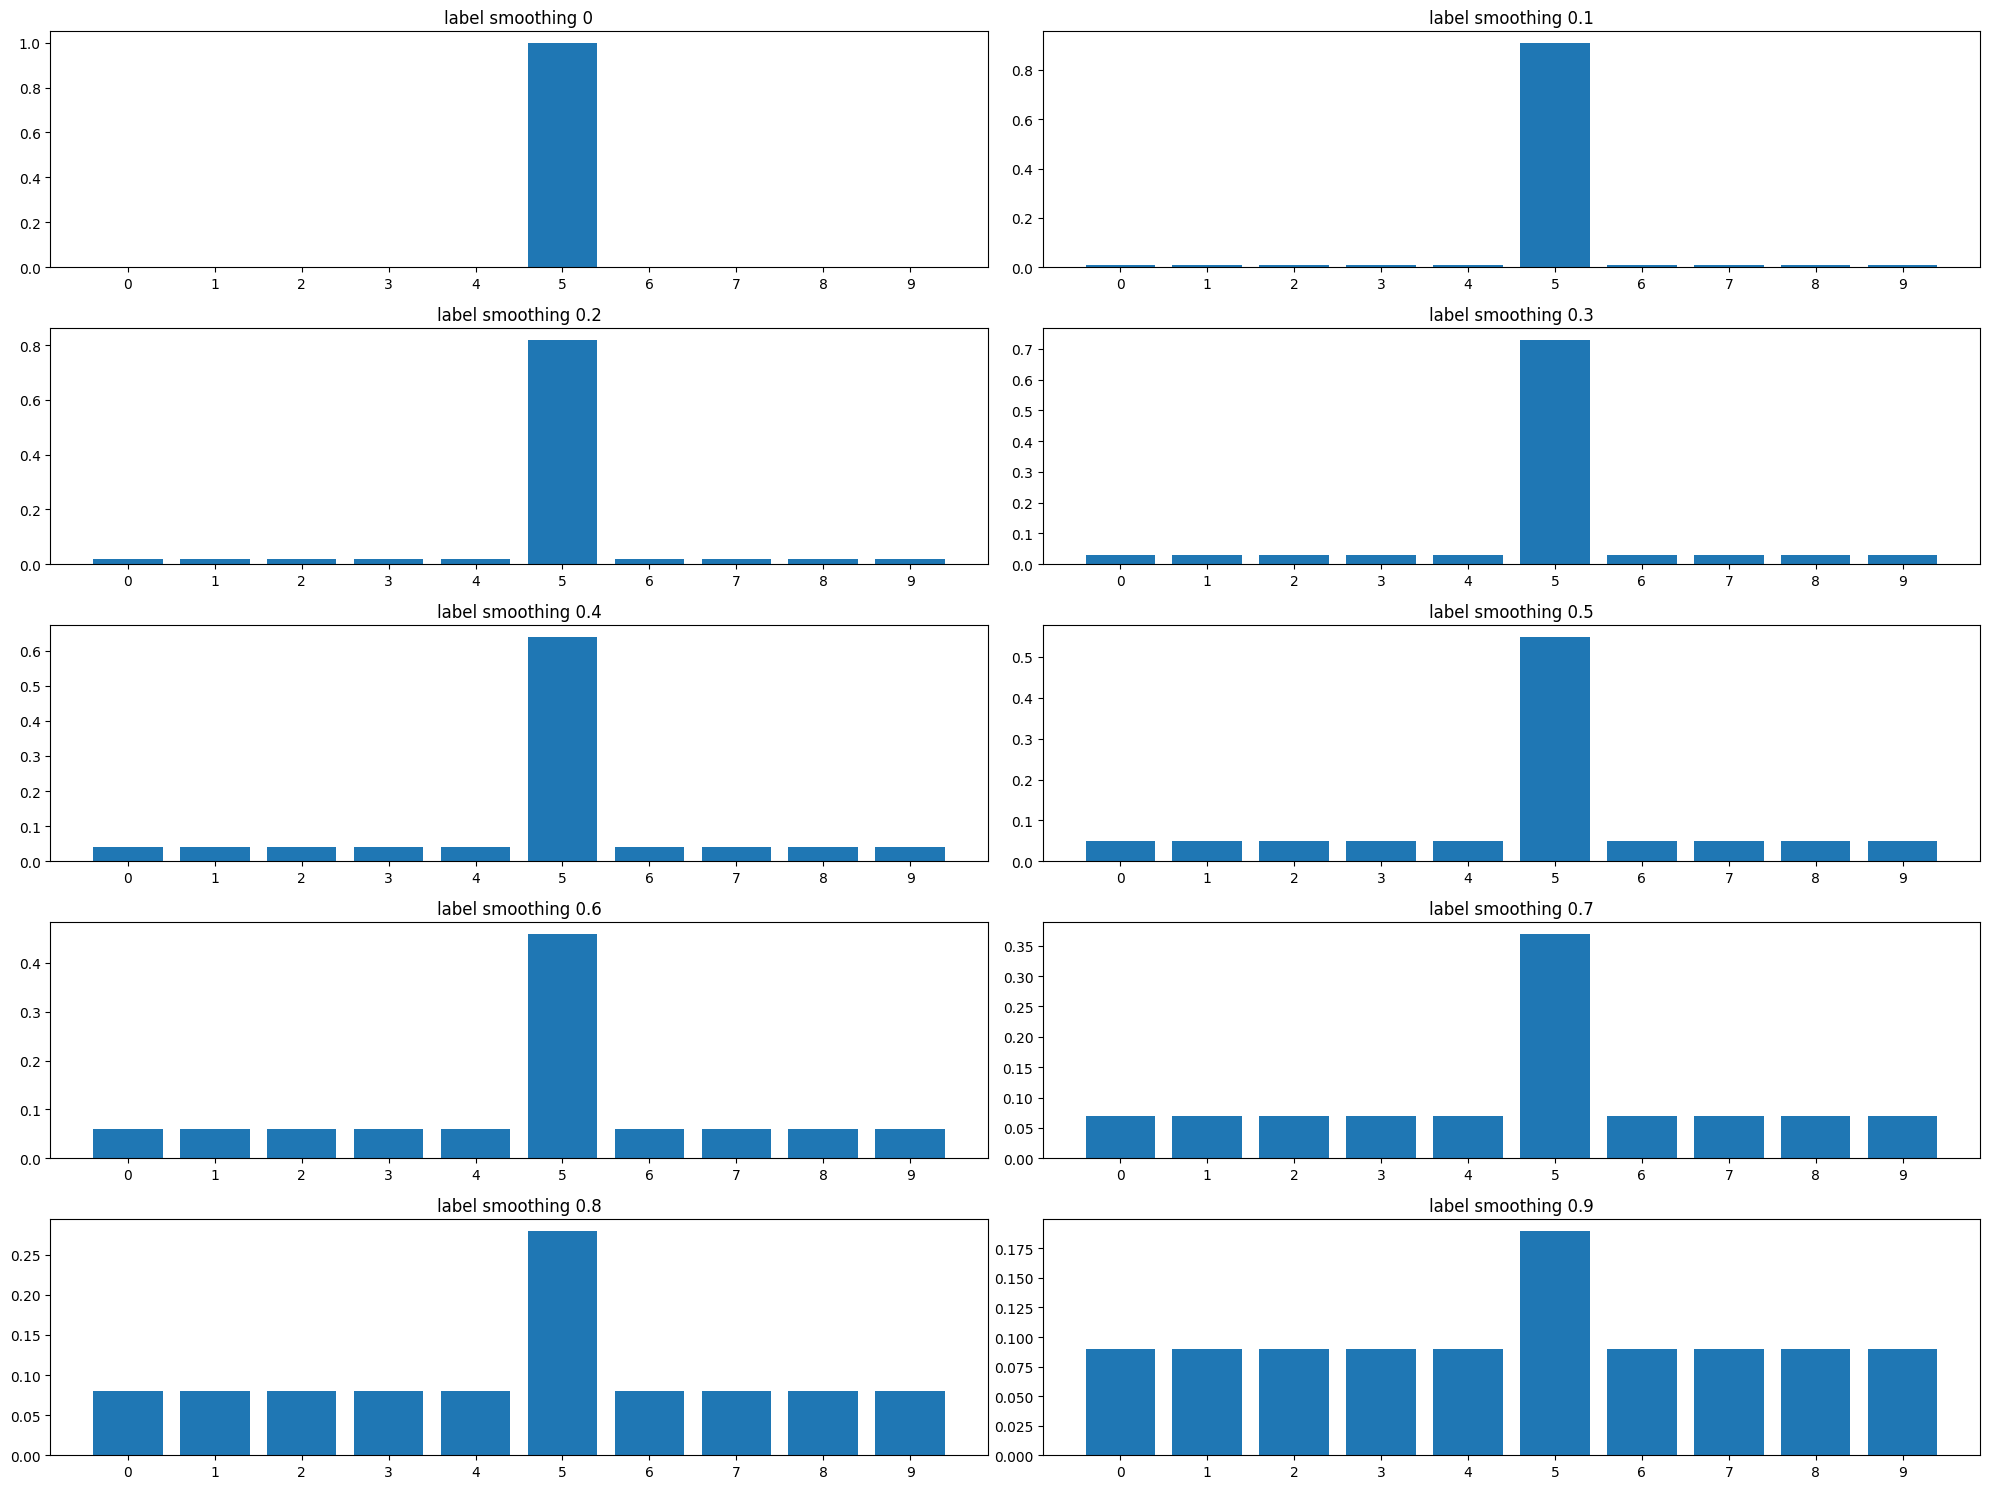

In [2]:
"""
以10个类别、类别为5为例，展示不同label smoothing程度的软标签。
"""
import numpy as np

onehot_label = np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])
uniform_label = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

label_smoothing_lambdas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plt.figure(figsize=(20, 15))
for i, label_smoothing_lambda in enumerate(label_smoothing_lambdas):
    plt.subplot(5, 2, i + 1)
    plt.bar([_ for _ in range(10)], (1 - label_smoothing_lambda) * onehot_label + label_smoothing_lambda * uniform_label)
    plt.xticks([_ for _ in range(10)], [_ for _ in range(10)])
    plt.title(f'label smoothing {label_smoothing_lambda}')
plt.tight_layout()
plt.show()

### 1.2.2 使用PyTorch实现Label Smoothing分类损失

In [3]:
"""
    首先，实现soft label，将标签（形式如torch.tensor([0, 1, 2, 3, 4])）转化为one-
hot向量（形式为torch.tensor([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 1, 0, 0],[0, 
0, 0, 1, 0], [0, 0, 0, 0, 1]])）
    此处torch.scatter函数在全0向量的指定位置写入1，参考：
    https://pytorch.org/docs/1.7.1/tensors.html?highlight=torch%20scatter#torch.Tensor.scatter

"""
num_classes = 5
label = torch.tensor([0, 1, 2, 3, 4])
soft_one_hot = torch.scatter(torch.zeros((label.shape[0], num_classes)),  # 全0向量
                             dim=1,                                       # 进行scatter的维度
                             index=label.unsqueeze(1),                    # 指定位置
                             value=1.                                     # 写入固定值1.
                            )

# 检查结果
print('标签:\n', label)
print('one-hot向量:\n', soft_one_hot)

标签:
 tensor([0, 1, 2, 3, 4])
one-hot向量:
 tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])


In [4]:
"""
    实现label smoothing soft label
"""
# 定义均匀分布概率向量
soft_uniform = 1 / num_classes * torch.ones((label.shape[0], num_classes))

# 定义 label smoothing 系数
alpha = 0.5

# 将均匀分布概率向量和one-hot向量进行加权
soft_label = alpha * soft_uniform + (1 - alpha) * soft_one_hot

# 检查结果
print('均匀分布向量:\n', soft_uniform)
print('label smoothing软标签:\n', soft_label)

均匀分布向量:
 tensor([[0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])
label smoothing软标签:
 tensor([[0.6000, 0.1000, 0.1000, 0.1000, 0.1000],
        [0.1000, 0.6000, 0.1000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.6000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000, 0.6000, 0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.6000]])


In [5]:
# 计算交叉熵损失
logits = torch.rand((label.shape[0], num_classes))  # 随机生成一个tensor作为logits
log_softmax = F.log_softmax(logits, dim=1)          # 用pytorch内建函数同时进行softmax和log运算
loss = (-log_softmax * soft_label).sum(dim=1)       # 计算交叉熵损失

print(loss)

tensor([1.6514, 1.7290, 1.7153, 1.6641, 1.5314])


In [6]:
# 将以上代码进行整合，实现一个label smoothing 交叉熵损失函数类
class LabelSmoothingCrossEntropyLoss(nn.Module):
    def __init__(self, label_smoothing=0.0, reduction='mean'):
        super(LabelSmoothingCrossEntropyLoss, self).__init__()
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, y, target):
        # 获取总类别数
        c = y.shape[1]
        
        # 将target转化为label smoothing的soft label
        # 1) 将target转化为one-hot形式的概率向量，此处torch.scatter函数在全0向量的指定位置写入1.，
        # 参考https://pytorch.org/docs/1.7.1/tensors.html?highlight=torch%20scatter#torch.Tensor.scatter
        soft_one_hot = torch.scatter(torch.zeros_like(y), dim=1, index=target.unsqueeze(1), value=1.)
        # 2) 定义均匀分布概率向量
        soft_uniform = 1/c * torch.ones_like(y)
        # 3) 计算label smoothing soft label
        soft_label = self.label_smoothing * soft_uniform + (1 - self.label_smoothing) * soft_one_hot

        # 计算交叉熵损失
        loss = (-F.log_softmax(y, dim=1) * soft_label).sum(dim=1)
        if self.reduction == 'sum':
            return loss.sum()
        elif self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'none':
            return loss
        else:
            raise NotImplementedError

In [7]:
# 检查结果是否一致
lsce = LabelSmoothingCrossEntropyLoss(label_smoothing=0.5, reduction='none')
print(lsce(logits, label))

tensor([1.6514, 1.7290, 1.7153, 1.6641, 1.5314])
